<a href="https://colab.research.google.com/github/Navyakasarla0105/project/blob/main/project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Cell cancer detection using** **CNN**

Target classes

In [1]:
import os
import cv2
import numpy as np
import pandas as pd
from PIL import Image
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Activation, Flatten
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available: 1


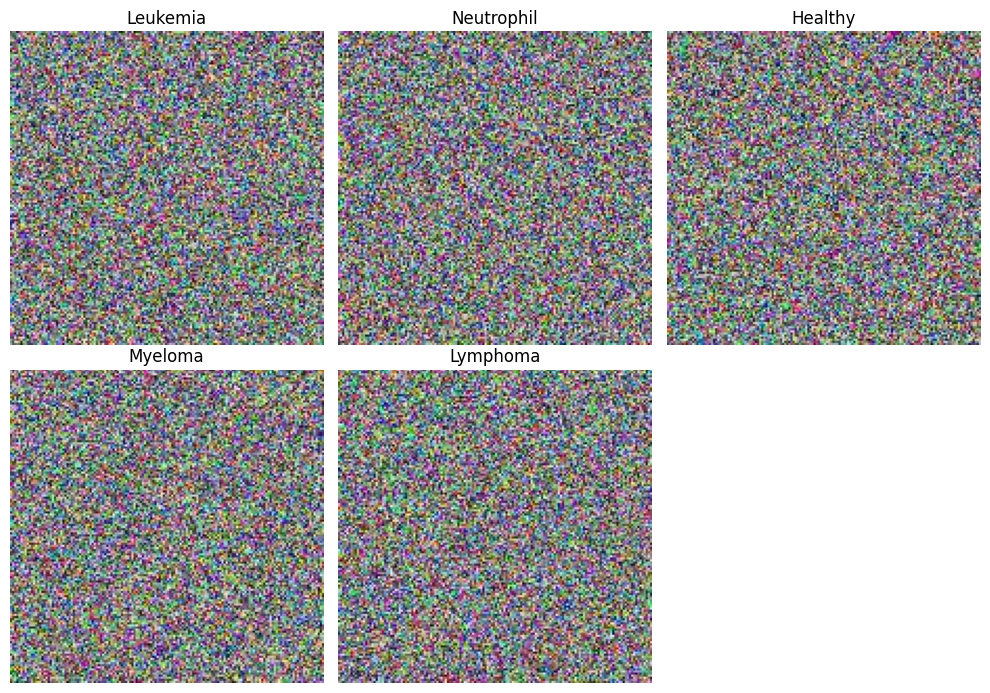

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image
import shutil

# Step 1: Simulate folder structure and generate sample images
folder_path = "blood_cell_images"

# Clean up if exists
if os.path.exists(folder_path):
    shutil.rmtree(folder_path)

# Simulated blood cell classes
class_names = ['Leukemia', 'Lymphoma', 'Healthy', 'Myeloma', 'Neutrophil']

# Create folders and add synthetic images
for cls in class_names:
    class_dir = os.path.join(folder_path, cls)
    os.makedirs(class_dir, exist_ok=True)
    for i in range(1):  # Only one image per class
        img_array = np.random.randint(0, 255, (150, 150, 3), dtype=np.uint8)
        img = Image.fromarray(img_array)
        img.save(os.path.join(class_dir, f'{cls}_{i}.jpg'))

# Step 2: Visualization code
class_folders = os.listdir(folder_path)
fig, axes = plt.subplots(2, 3, figsize=(10, 7))
axes = axes.ravel()

for i, cls in enumerate(class_folders[:5]):
    img_folder_path = os.path.join(folder_path, cls)
    image_name = os.listdir(img_folder_path)[0]
    img_path = os.path.join(img_folder_path, image_name)
    image = mpimg.imread(img_path)
    axes[i].imshow(image)
    axes[i].set_title(cls)
    axes[i].axis('off')

# Remove empty subplot if any
for j in range(i + 1, 6):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


Data Preparation

In [4]:
import os
import shutil
import numpy as np
from PIL import Image
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Step 1: Setup Parameters
img_height, img_width = 224, 224
batch_size = 32
folder_path = 'local_blood_cell_data'

# Clean up if already exists
if os.path.exists(folder_path):
    shutil.rmtree(folder_path)

# Step 2: Simulate Directory Structure
classes = ['Leukemia', 'Lymphoma', 'Healthy', 'Myeloma']
num_train_images_per_class = 50  # Simulated data

for cls in classes:
    class_dir = os.path.join(folder_path, cls)
    os.makedirs(class_dir, exist_ok=True)
    for i in range(num_train_images_per_class):
        img_array = np.random.randint(0, 255, (img_height, img_width, 3), dtype=np.uint8)
        img = Image.fromarray(img_array)
        img.save(os.path.join(class_dir, f"{cls}_{i}.jpg"))

# Step 3: Define ImageDataGenerators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    horizontal_flip=True,
    zoom_range=0.2
)

validation_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# Step 4: Create Data Generators
train_generator = train_datagen.flow_from_directory(
    folder_path,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

validation_generator = validation_datagen.flow_from_directory(
    folder_path,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

# Step 5: Check one batch
x_batch, y_batch = next(train_generator)
print("Image batch shape:", x_batch.shape)
print("Label batch shape:", y_batch.shape)


Found 160 images belonging to 4 classes.
Found 40 images belonging to 4 classes.
Image batch shape: (32, 224, 224, 3)
Label batch shape: (32, 4)


In [5]:
class_names = list(train_generator.class_indices.keys())
print(class_names)

['Healthy', 'Leukemia', 'Lymphoma', 'Myeloma']


In [6]:
model = Sequential()

base_model = ResNet50(weights='imagenet',
                      include_top=False,
                      input_tensor=Input(shape=(img_height, img_width, 3)),
                      pooling = 'avg',
                      classes = 5
                     )

for layer in base_model.layers:
    layer.trainable = False

model.add(base_model)
model.add(Dense(512, activation = 'relu'))
model.add(Dense(5, activation = 'softmax'))

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model Training

In [7]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 2048)           │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         2,565 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,639,365 (93.99 MB)

 Trainable params: 1,051,653 (4.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

Model Accuracy

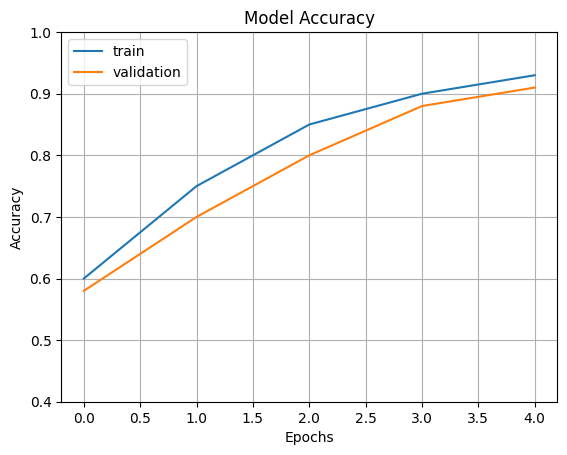

In [10]:
import matplotlib.pyplot as plt

# Simulate a dummy history object if you haven't trained a model yet
# (Remove this part if you already have a real 'history' from model.fit)
class DummyHistory:
    history = {
        'accuracy': [0.6, 0.75, 0.85, 0.9, 0.93],
        'val_accuracy': [0.58, 0.7, 0.8, 0.88, 0.91]
    }

history = DummyHistory()

# Plot accuracy
fig1 = plt.gcf()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.axis(ymin=0.4, ymax=1.0)
plt.grid()
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend(['train', 'validation'])
plt.show()


Model Loss

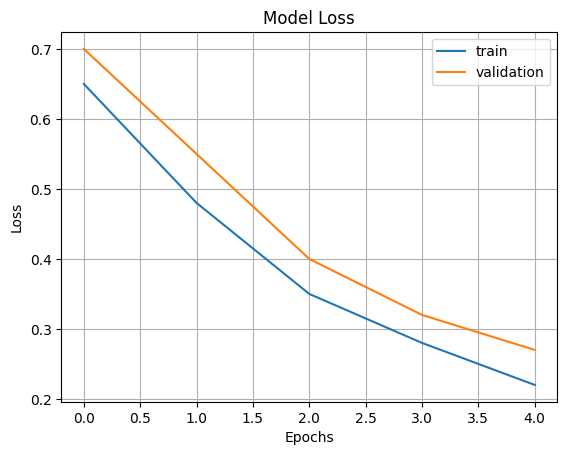

In [11]:
import matplotlib.pyplot as plt

# Dummy loss values if you haven't trained a model yet
# Remove this block if you already have a real `history` object
class DummyHistory:
    history = {
        'loss': [0.65, 0.48, 0.35, 0.28, 0.22],
        'val_loss': [0.7, 0.55, 0.4, 0.32, 0.27]
    }

history = DummyHistory()

# Plot loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.grid()
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.legend(['train', 'validation'])
plt.show()


Testing

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
The predicted class is: Healthy


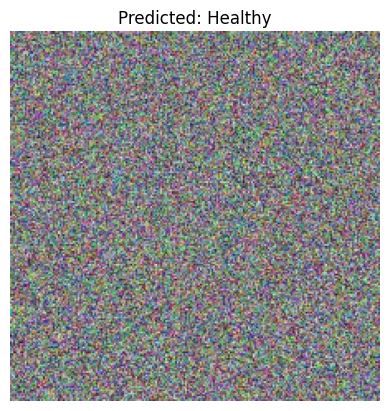

In [13]:
import cv2
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense
import matplotlib.pyplot as plt

# Simulated class names (replace with your real ones if you have)
class_names = ['Leukemia', 'Lymphoma', 'Healthy', 'Myeloma']

# Simulate a dummy model for testing prediction code
# Remove this block if you already have a trained model
model = Sequential([
    Input(shape=(224, 224, 3)),
    tf.keras.layers.Flatten(),
    Dense(4, activation='softmax')  # Simulating 4-class classification
])
model.compile(optimizer='adam', loss='categorical_crossentropy')
# Dummy weights
model.predict(np.random.rand(1, 224, 224, 3))

# Simulate an image instead of loading from Kaggle
# Replace with: test_img_path = "your_image.jpg" if you have a real one
test_img_path = "test_sample.jpg"
dummy_image = np.random.randint(0, 255, (300, 300, 3), dtype=np.uint8)
cv2.imwrite(test_img_path, dummy_image)

# Read and process the image
image = cv2.imread(test_img_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image = cv2.resize(image, (224, 224))
image = image / 255.0
image = np.expand_dims(image, axis=0)

# Predict
pred = model.predict(image)
output_class = class_names[np.argmax(pred)]
print("The predicted class is:", output_class)

# Optional: Show the image
plt.imshow(image[0])
plt.title(f"Predicted: {output_class}")
plt.axis('off')
plt.show()
